<a href="https://colab.research.google.com/github/laithmusallam/nba-scoring-versatility-playoff-analysis/blob/main/NBA_Scoring_Versatility_and_Playoff_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***NBA Scoring Versatility and Playoff Performance Analysis***

---

This project investigates whether scoring versatility helps NBA players maintain offensive efficiency during the playoffs.

Using NBA API shot-location data across multiple seasons, players were classified into scoring archetypes and analyzed based on playoff true shooting percentage changes.

# Data Collection and Preparation

---

In [ ]:
# Install required libraries for data extraction, analysis, and visualization
# nba_api: pull NBA data directly
# pandas/numpy: data manipulation
# matplotlib/seaborn: visualization
!pip install nba_api pandas matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 5.8 MB/s eta 0:00:00


In [ ]:
# Import core libraries for data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import NBA API endpoint for player-level statistics
from nba_api.stats.endpoints import leaguedashplayerstats, leaguedashplayershotlocations

In [ ]:
# ================================
# Step 3: Pull Regular Season Player Data
# ================================

# Start with one season to validate the workflow before scaling across multiple seasons
season = "2022-23"

# Pull player-level regular season stats from NBA.com
regular_season_request = leaguedashplayerstats.LeagueDashPlayerStats(
    season=season,
    season_type_all_star="Regular Season"
)

# Convert the NBA API response into a pandas DataFrame
regular_season_data = regular_season_request.get_data_frames()[0]

# Preview the raw regular season dataset
regular_season_data.head()

,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,...,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT
0,1630639,A.J. Lawson,A.J.,1610612742,DAL,22.0,15,5,10,0.333,...,96,74,457,437,369,466,253,39,461,2
1,1631260,AJ Green,AJ,1610612749,MIL,23.0,35,27,8,0.771,...,42,132,471,383,327,406,253,39,401,1
2,1631100,AJ Griffin,AJ,1610612737,ATL,19.0,72,34,38,0.472,...,336,272,318,185,127,230,253,39,219,1
3,203932,Aaron Gordon,Aaron,1610612743,DEN,27.0,68,45,23,0.662,...,517,385,51,83,2,69,56,39,81,1
4,1628988,Aaron Holiday,Aaron,1610612737,ATL,26.0,63,32,31,0.508,...,277,250,282,326,186,324,253,39,323,1


In [ ]:
# ================================
# Step 4: Inspect Available Columns
# ================================

# Review all returned columns so we can intentionally select only what we need
regular_season_data.columns.tolist()

['PLAYER_ID',
 'PLAYER_NAME',
 'NICKNAME',
 'TEAM_ID',
 'TEAM_ABBREVIATION',
 'AGE',
 'GP',
 'W',
 'L',
 'W_PCT',
 'MIN',
 'FGM',
 'FGA',
 'FG_PCT',
 'FG3M',
 'FG3A',
 'FG3_PCT',
 'FTM',
 'FTA',
 'FT_PCT',
 'OREB',
 'DREB',
 'REB',
 'AST',
 'TOV',
 'STL',
 'BLK',
 'BLKA',
 'PF',
 'PFD',
 'PTS',
 'PLUS_MINUS',
 'NBA_FANTASY_PTS',
 'DD2',
 'TD3',
 'WNBA_FANTASY_PTS',
 'GP_RANK',
 'W_RANK',
 'L_RANK',
 'W_PCT_RANK',
 'MIN_RANK',
 'FGM_RANK',
 'FGA_RANK',
 'FG_PCT_RANK',
 'FG3M_RANK',
 'FG3A_RANK',
 'FG3_PCT_RANK',
 'FTM_RANK',
 'FTA_RANK',
 'FT_PCT_RANK',
 'OREB_RANK',
 'DREB_RANK',
 'REB_RANK',
 'AST_RANK',
 'TOV_RANK',
 'STL_RANK',
 'BLK_RANK',
 'BLKA_RANK',
 'PF_RANK',
 'PFD_RANK',
 'PTS_RANK',
 'PLUS_MINUS_RANK',
 'NBA_FANTASY_PTS_RANK',
 'DD2_RANK',
 'TD3_RANK',
 'WNBA_FANTASY_PTS_RANK',
 'TEAM_COUNT']

# ***Research Question 1: Three-Point Reliance and Playoff Efficiency***
The first layer of this project explores whether players who rely heavily on three-point attempts experience larger efficiency drops in the playoffs.

To test this, I calculate each player's regular season True Shooting Percentage (TS%) and Three-Point Attempt Rate (3PA Rate), then compare those metrics against playoff performance.

This serves as the foundation before expanding into the larger question of whether three-level scorers with more diverse shot profiles maintain performance better in postseason environments.

In [ ]:
# ================================
# Step 5: Select Relevant Columns
# ================================

# For the first layer of analysis, we only need:
# - player identifiers
# - team context
# - games played
# - scoring volume
# - shot attempts
# - free throw attempts
# - three-point attempts

regular_season_selected = regular_season_data[
    [
        "PLAYER_ID",          # Unique player ID, useful for merging with playoff data later
        "PLAYER_NAME",        # Player name for readability
        "TEAM_ABBREVIATION",  # Team context
        "GP",                 # Games played, used for sample-size filtering
        "PTS",                # Total points, used for True Shooting %
        "FGA",                # Field goal attempts, used for True Shooting % and volume filtering
        "FTA",                # Free throw attempts, used for True Shooting %
        "FG3A"                # Three-point attempts, used for 3PA Rate
    ]
].copy()

# Preview the focused regular season dataset
regular_season_selected.head()

,PLAYER_ID,PLAYER_NAME,TEAM_ABBREVIATION,GP,PTS,FGA,FTA,FG3A
0,1630639,A.J. Lawson,DAL,15,56,44,8,25
1,1631260,AJ Green,MIL,35,154,125,4,105
2,1631100,AJ Griffin,ATL,72,639,533,47,259
3,203932,Aaron Gordon,DEN,68,1109,761,314,173
4,1628988,Aaron Holiday,ATL,63,247,220,32,88


In [ ]:
# ================================
# Step 6: Create Key Metrics
# ================================

# True Shooting % measures overall scoring efficiency
# It includes 2-point shots, 3-point shots, and free throws in one efficiency metric
regular_season_selected["TS_pct"] = regular_season_selected["PTS"] / (
    2 * (regular_season_selected["FGA"] + 0.44 * regular_season_selected["FTA"])
)

# 3PA Rate measures how much of a player's shot profile comes from three-point attempts
regular_season_selected["ThreePA_rate"] = (
    regular_season_selected["FG3A"] / regular_season_selected["FGA"]
)

# Preview the dataset with new calculated metrics
regular_season_selected.head()

,PLAYER_ID,PLAYER_NAME,TEAM_ABBREVIATION,GP,PTS,FGA,FTA,FG3A,TS_pct,ThreePA_rate
0,1630639,A.J. Lawson,DAL,15,56,44,8,25,0.589226,0.568182
1,1631260,AJ Green,MIL,35,154,125,4,105,0.607447,0.840000
2,1631100,AJ Griffin,ATL,72,639,533,47,259,0.577048,0.485929
3,203932,Aaron Gordon,DEN,68,1109,761,314,173,0.616687,0.227332
4,1628988,Aaron Holiday,ATL,63,247,220,32,88,0.527597,0.400000


In [ ]:
# ================================
# Step 7: Clean and Prepare Dataset
# ================================

# Filter out small sample sizes
# GP >= 30 ensures meaningful participation
# FGA >= 300 ensures real offensive volume

regular_season_cleaned = regular_season_selected[
    (regular_season_selected["GP"] >= 30) &
    (regular_season_selected["FGA"] >= 300)
].copy()

# Remove missing values
regular_season_cleaned = regular_season_cleaned.dropna()

# Replace infinite values (from division issues) with NaN, then drop them
regular_season_cleaned = regular_season_cleaned.replace([np.inf, -np.inf], np.nan).dropna()

# -------------------------------
# Create display-friendly percentages
# -------------------------------

regular_season_cleaned["TS_pct_display"] = (regular_season_cleaned["TS_pct"] * 100).round(1)
regular_season_cleaned["ThreePA_rate_display"] = (regular_season_cleaned["ThreePA_rate"] * 100).round(1)

# -------------------------------
# Create a clean presentation table
# -------------------------------

regular_season_display = regular_season_cleaned.rename(columns={
    "PLAYER_NAME": "Player",
    "TEAM_ABBREVIATION": "Team",
    "GP": "Games",
    "PTS": "Points",
    "FGA": "FGA",
    "FG3A": "3PA",
    "TS_pct_display": "TS%",
    "ThreePA_rate_display": "3PA%"
})[
    ["Player", "Team", "Games", "Points", "FGA", "3PA", "TS%", "3PA%"]
]

# Preview the cleaned, readable dataset
regular_season_display.head()

,Player,Team,Games,Points,FGA,3PA,TS%,3PA%
2,AJ Griffin,ATL,72,639,533,259,57.7,48.6
3,Aaron Gordon,DEN,68,1109,761,173,61.7,22.7
5,Aaron Nesmith,IND,73,738,590,314,56.6,53.2
6,Aaron Wiggins,OKC,70,479,363,122,60.7,33.6
8,Al Horford,BOS,63,616,479,325,63.1,67.8


In [ ]:
# ================================
# Step 8: Identify Regular Season High 3-Point Reliance Players
# ================================

# Define players who rely heavily on three-point shooting
# Using 35% as a threshold captures both stars and high-volume shooters
# Threshold choice:
# A 35% 3PA rate is used to capture players with above-average three-point reliance
# while still including primary scorers. Alternative thresholds (30%, 40%) could
# be tested to validate the robustness of results.

high_three_point_players = regular_season_display[
    regular_season_display["3PA%"] >= 35
].sort_values(
    by="TS%",
    ascending=False
).head(10)

high_three_point_players

,Player,Team,Games,Points,FGA,3PA,TS%,3PA%
26,Austin Reaves,LAL,64,833,490,216,68.7,44.1
343,Luke Kennard,MEM,59,546,382,269,68.4,70.4
83,Corey Kispert,WAS,74,820,585,384,65.7,65.6
471,Stephen Curry,GSW,56,1648,1133,639,65.6,56.4
504,Trey Murphy III,NOP,79,1148,800,497,65.0,62.1
271,Josh Green,DAL,60,546,382,169,64.5,44.2
90,Damian Lillard,POR,58,1866,1202,658,64.5,54.7
296,Kelly Olynyk,UTA,68,847,557,236,64.3,42.4
331,Lauri Markkanen,UTA,66,1691,1145,511,64.0,44.6
454,Sam Hauser,BOS,80,512,396,335,63.4,84.6


In [ ]:
# ================================
# Step 9: Pull Playoff Data
# ================================

# Pull player-level playoff stats for the same season
playoff_request = leaguedashplayerstats.LeagueDashPlayerStats(
    season=season,
    season_type_all_star="Playoffs"
)

# Convert API response into DataFrame
playoff_data = playoff_request.get_data_frames()[0]

# Preview playoff dataset
playoff_data.head()

,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,...,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT
0,203932,Aaron Gordon,Aaron,1610612743,DEN,27.0,20,16,4,0.800,...,212,212,14,19,1,16,22,6,15,1
1,1628988,Aaron Holiday,Aaron,1610612737,ATL,26.0,1,1,0,1.000,...,1,1,182,194,90,207,58,6,202,1
2,201143,Al Horford,Al,1610612738,BOS,37.0,20,11,9,0.550,...,136,206,94,44,11,15,37,6,21,1
3,203458,Alex Len,Alex,1610612758,SAC,30.0,7,3,4,0.429,...,83,128,112,146,29,139,58,6,140,1
4,1629599,Amir Coffey,Amir,1610612746,LAC,26.0,1,0,1,0.000,...,1,1,182,194,85,210,58,6,210,1


In [ ]:
# ================================
# Step 10: Select Relevant Playoff Columns
# ================================

# Use the same core columns from the playoff dataset so it can be compared
# directly against regular season performance.

playoff_selected = playoff_data[
    [
        "PLAYER_ID",
        "PLAYER_NAME",
        "TEAM_ABBREVIATION",
        "GP",
        "PTS",
        "FGA",
        "FTA",
        "FG3A"
    ]
].copy()

# Preview focused playoff dataset
playoff_selected.head()

,PLAYER_ID,PLAYER_NAME,TEAM_ABBREVIATION,GP,PTS,FGA,FTA,FG3A
0,203932,Aaron Gordon,DEN,20,265,195,69,46
1,1628988,Aaron Holiday,ATL,1,0,0,0,0
2,201143,Al Horford,BOS,20,133,132,4,94
3,203458,Alex Len,SAC,7,19,9,6,0
4,1629599,Amir Coffey,LAC,1,0,0,0,0


In [ ]:
# ================================
# Step 11: Create Playoff Metrics
# ================================

# Calculate playoff True Shooting %
playoff_selected["Playoff_TS_pct"] = playoff_selected["PTS"] / (
    2 * (playoff_selected["FGA"] + 0.44 * playoff_selected["FTA"])
)

# Calculate playoff 3PA Rate
playoff_selected["Playoff_ThreePA_rate"] = (
    playoff_selected["FG3A"] / playoff_selected["FGA"]
)

# Preview playoff dataset with calculated metrics
playoff_selected.head()

,PLAYER_ID,PLAYER_NAME,TEAM_ABBREVIATION,GP,PTS,FGA,FTA,FG3A,Playoff_TS_pct,Playoff_ThreePA_rate
0,203932,Aaron Gordon,DEN,20,265,195,69,46,0.587948,0.235897
1,1628988,Aaron Holiday,ATL,1,0,0,0,0,NaN,NaN
2,201143,Al Horford,BOS,20,133,132,4,94,0.497159,0.712121
3,203458,Alex Len,SAC,7,19,9,6,0,0.816151,0.000000
4,1629599,Amir Coffey,LAC,1,0,0,0,0,NaN,NaN


In [ ]:
# ================================
# Step 12: Clean and Prepare Playoff Dataset
# ================================

# Playoff samples are naturally smaller, so the filters need to be lighter.
# GP >= 3 removes players with tiny playoff appearances.
# FGA >= 30 keeps players with at least some offensive volume.

playoff_cleaned = playoff_selected[
    (playoff_selected["GP"] >= 3) &
    (playoff_selected["FGA"] >= 30)
].copy()

# Remove missing values
playoff_cleaned = playoff_cleaned.dropna()

# Replace infinite values from possible division issues with NaN, then drop them
playoff_cleaned = playoff_cleaned.replace([np.inf, -np.inf], np.nan).dropna()

# -------------------------------
# Create display-friendly percentages
# -------------------------------

playoff_cleaned["Playoff_TS_pct_display"] = (playoff_cleaned["Playoff_TS_pct"] * 100).round(1)
playoff_cleaned["Playoff_ThreePA_rate_display"] = (playoff_cleaned["Playoff_ThreePA_rate"] * 100).round(1)

# -------------------------------
# Create a clean presentation table
# -------------------------------

playoff_display = playoff_cleaned.rename(columns={
    "PLAYER_NAME": "Player",
    "TEAM_ABBREVIATION": "Team",
    "GP": "Playoff Games",
    "PTS": "Playoff Points",
    "FGA": "Playoff FGA",
    "FG3A": "Playoff 3PA",
    "Playoff_TS_pct_display": "Playoff TS%",
    "Playoff_ThreePA_rate_display": "Playoff 3PA%"
})[
    ["Player", "Team", "Playoff Games", "Playoff Points", "Playoff FGA", "Playoff 3PA", "Playoff TS%", "Playoff 3PA%"]
]

# Preview the cleaned, readable playoff dataset
playoff_display.head()

,Player,Team,Playoff Games,Playoff Points,Playoff FGA,Playoff 3PA,Playoff TS%,Playoff 3PA%
0,Aaron Gordon,DEN,20,265,195,46,58.8,23.6
2,Al Horford,BOS,20,133,132,94,49.7,71.2
5,Andrew Wiggins,GSW,13,217,181,64,53.8,35.4
6,Anthony Davis,LAL,16,361,254,15,59.9,5.9
7,Anthony Edwards,MIN,5,158,114,43,60.2,37.7


In [ ]:
# ================================
# Step 13: Merge Regular Season and Playoff Data
# ================================

# Merge datasets on PLAYER_ID (unique identifier)
player_season_vs_playoffs = regular_season_cleaned.merge(
    playoff_cleaned,
    on="PLAYER_ID",
    suffixes=("_reg", "_playoffs")
)

# Preview merged dataset
player_season_vs_playoffs.head()

,PLAYER_ID,PLAYER_NAME_reg,TEAM_ABBREVIATION_reg,GP_reg,PTS_reg,FGA_reg,FTA_reg,FG3A_reg,TS_pct,ThreePA_rate,...,TEAM_ABBREVIATION_playoffs,GP_playoffs,PTS_playoffs,FGA_playoffs,FTA_playoffs,FG3A_playoffs,Playoff_TS_pct,Playoff_ThreePA_rate,Playoff_TS_pct_display,Playoff_ThreePA_rate_display
0,203932,Aaron Gordon,DEN,68,1109,761,314,173,0.616687,0.227332,...,DEN,20,265,195,69,46,0.587948,0.235897,58.8,23.6
1,201143,Al Horford,BOS,63,616,479,21,325,0.630837,0.678497,...,BOS,20,133,132,4,94,0.497159,0.712121,49.7,71.2
2,203952,Andrew Wiggins,GSW,37,633,529,72,225,0.564493,0.425331,...,GSW,13,217,181,47,64,0.537981,0.353591,53.8,35.4
3,203076,Anthony Davis,LAL,56,1451,962,444,74,0.626858,0.076923,...,LAL,16,361,254,108,15,0.598634,0.059055,59.9,5.9
4,1630162,Anthony Edwards,MIN,79,1946,1541,422,578,0.563509,0.375081,...,MIN,5,158,114,39,43,0.602318,0.377193,60.2,37.7


In [ ]:
# ================================
# Step 14: Calculate Efficiency Change (Regular Season vs Playoffs)
# ================================

# Calculate True Shooting % difference
# Positive = player was less efficient in playoffs
# Negative = player was more efficient in playoffs
player_season_vs_playoffs["TS_drop"] = (
    player_season_vs_playoffs["TS_pct"] -
    player_season_vs_playoffs["Playoff_TS_pct"]
)

# Convert to readable percentage format
player_season_vs_playoffs["TS_drop_display"] = (
    player_season_vs_playoffs["TS_drop"] * 100
).round(1)

# Create a clean, readable comparison table
season_vs_playoffs_display = player_season_vs_playoffs.rename(columns={
    "PLAYER_NAME_reg": "Player",
    "TEAM_ABBREVIATION_reg": "Team",
    "TS_pct_display": "Regular TS%",
    "Playoff_TS_pct_display": "Playoff TS%",
    "TS_drop_display": "TS Change (%)",
    "ThreePA_rate_display": "Regular 3PA%"
})[
    ["Player", "Team", "Regular TS%", "Playoff TS%", "TS Change (%)", "Regular 3PA%"]
]

# Sort by biggest TS% drop
season_vs_playoffs_display = season_vs_playoffs_display.sort_values(
    by="TS Change (%)",
    ascending=False
)

# Preview
season_vs_playoffs_display.head(10)

,Player,Team,Regular TS%,Playoff TS%,TS Change (%),Regular 3PA%
66,Kevin Huerter,SAC,61.7,42.4,19.3,58.9
104,Tyus Jones,MEM,54.6,36.2,18.4,45.9
88,Quentin Grimes,NYK,61.9,45.2,16.7,67.6
31,Domantas Sabonis,SAC,66.8,51.7,15.1,8.8
1,Al Horford,BOS,63.1,49.7,13.4,67.8
58,Jordan Poole,GSW,57.3,44.7,12.7,49.8
36,Evan Mobley,CLE,59.1,47.6,11.5,10.8
42,Harrison Barnes,SAC,63.2,52.5,10.7,44.6
50,Jarred Vanderbilt,LAL,60.4,50.1,10.3,20.0
30,Dillon Brooks,MEM,49.4,39.3,10.1,44.3


In [ ]:
# ================================
# Step 15: Analyze Impact of 3PA Rate on TS Drop
# ================================

# HYPOTHESIS:

# Players with higher reliance on three-point attempts will experience
# larger efficiency drops in the playoffs due to tighter defense running them off the perimeter and reduced shot quality.

# Create groups based on 3PA rate
# Using 35% threshold (as discussed earlier)

player_season_vs_playoffs["ThreePA_Group"] = (
    player_season_vs_playoffs["ThreePA_rate"] >= 0.35
)

# Convert True/False → readable labels
player_season_vs_playoffs["ThreePA_Group"] = player_season_vs_playoffs["ThreePA_Group"].map({
    True: "High 3PA (>=35%)",
    False: "Low 3PA (<35%)"
})

# ================================
# Compare average TS drop by group
# ================================

three_pa_analysis = player_season_vs_playoffs.groupby("ThreePA_Group").agg({
    "TS_drop": "mean"
}).reset_index()

# Convert to % for readability
three_pa_analysis["Avg TS Change (%)"] = (three_pa_analysis["TS_drop"] * 100).round(2)

# Keep clean display
three_pa_analysis = three_pa_analysis[[
    "ThreePA_Group", "Avg TS Change (%)"
]]

# Preview result
three_pa_analysis

,ThreePA_Group,Avg TS Change (%)
0,High 3PA (>=35%),2.54
1,Low 3PA (<35%),3.94


# ***Findings from Research Question 1***

The initial analysis explored whether players with higher three-point attempt rates experience larger efficiency declines in the playoffs.

Contrary to the initial hypothesis, results showed that players with lower three-point attempt rates experienced a greater average drop in True Shooting Percentage.

This suggests that players who rely less on perimeter shooting—often more interior-focused scorers—may be more affected by playoff defensive adjustments, such as increased paint protection and reduced transition opportunities.

However, this analysis does not account for shot diversity. It groups together all non-three-point-heavy players, including both one-dimensional interior scorers and more versatile offensive players.

This leads to the next phase of analysis: examining whether players with more balanced shot profiles (three-level scorers) demonstrate greater efficiency stability in playoff environments.

# Scoring Profile Classification

---

In [ ]:
# ============================================
# Step 16A: Pull Shot Location Data
# ============================================

# I am using NBA shot location data to move beyond overall efficiency metrics
# and evaluate how players distribute their shots across interior, midrange, and three-point zones.

shot_location_request = leaguedashplayershotlocations.LeagueDashPlayerShotLocations(
    season=season,
    season_type_all_star="Regular Season"
)

# Convert NBA API response into a pandas DataFrame
shot_location_data = shot_location_request.get_data_frames()[0]

# Preview the raw shot location dataset
shot_location_data.head()

SHOT_CATEGORY                                                               \
columns       PLAYER_ID    PLAYER_NAME     TEAM_ID TEAM_ABBREVIATION   AGE   
0               1630639    A.J. Lawson  1610612742               DAL  22.0   
1               1631260       AJ Green  1610612749               MIL  23.0   
2               1631100     AJ Griffin  1610612737               ATL  19.0   
3                203932   Aaron Gordon  1610612743               DEN  27.0   
4               1628988  Aaron Holiday  1610612737               ATL  26.0   

SHOT_CATEGORY          Restricted Area             In The Paint (Non-RA)  ...  \
columns       NICKNAME             FGM  FGA FG_PCT                   FGM  ...   
0                 A.J.              10   17  0.588                   2.0  ...   
1                   AJ               3    6  0.500                   2.0  ...   
2                   AJ              45   68  0.662                  71.0  ...   
3                Aaron             318  433  0.734                  37.0  ...   
4                Aaron              31   54  0.574                  16.0  ...   

SHOT_CATEGORY Right Corner 3 Above the Break 3               Backcourt       \
columns               FG_PCT               FGM    FGA FG_PCT       FGM  FGA   
0                      0.167               7.0   11.0  0.636       0.0  0.0   
1                      0.571              35.0   83.0  0.422       0.0  0.0   
2                      0.370              70.0  182.0  0.385       0.0  0.0   
3                      0.308              46.0  113.0  0.407       0.0  4.0   
4                      0.111              32.0   72.0  0.444       0.0  0.0   

SHOT_CATEGORY        Corner 3               
columns       FG_PCT      FGM   FGA FG_PCT  
0                0.0      3.0  14.0  0.214  
1                0.0      9.0  22.0  0.409  
2                0.0     31.0  77.0  0.403  
3                0.0     14.0  56.0  0.250  
4                0.0      4.0  16.0  0.250  

[5 rows x 30 columns]

In [ ]:
# ============================================
# Step 16B: Inspect Shot Location Columns
# ============================================

# NBA API shot-location columns can be named differently than standard box score columns,
# so I inspect the columns before selecting the exact shot zones needed for analysis.

shot_location_data.columns.tolist()

[('', np.str_('PLAYER_ID')),
 ('', np.str_('PLAYER_NAME')),
 ('', np.str_('TEAM_ID')),
 ('', np.str_('TEAM_ABBREVIATION')),
 ('', np.str_('AGE')),
 ('', np.str_('NICKNAME')),
 (np.str_('Restricted Area'), np.str_('FGM')),
 (np.str_('Restricted Area'), np.str_('FGA')),
 (np.str_('Restricted Area'), np.str_('FG_PCT')),
 (np.str_('In The Paint (Non-RA)'), np.str_('FGM')),
 (np.str_('In The Paint (Non-RA)'), np.str_('FGA')),
 (np.str_('In The Paint (Non-RA)'), np.str_('FG_PCT')),
 (np.str_('Mid-Range'), np.str_('FGM')),
 (np.str_('Mid-Range'), np.str_('FGA')),
 (np.str_('Mid-Range'), np.str_('FG_PCT')),
 (np.str_('Left Corner 3'), np.str_('FGM')),
 (np.str_('Left Corner 3'), np.str_('FGA')),
 (np.str_('Left Corner 3'), np.str_('FG_PCT')),
 (np.str_('Right Corner 3'), np.str_('FGM')),
 (np.str_('Right Corner 3'), np.str_('FGA')),
 (np.str_('Right Corner 3'), np.str_('FG_PCT')),
 (np.str_('Above the Break 3'), np.str_('FGM')),
 (np.str_('Above the Break 3'), np.str_('FGA')),
 (np.str_('Above

In [ ]:
# ============================================
# Step 16C: Build Three-Level Shot Profile
# ============================================

# I am selecting only field goal attempts (FGA) from each shot zone.
# For this part of the analysis, I care about shot distribution:
# where players are taking shots from, not whether they made them.

shot_profile = shot_location_data[
    [
        ("", "PLAYER_ID"),
        ("", "PLAYER_NAME"),
        ("", "TEAM_ABBREVIATION"),

        ("Restricted Area", "FGA"),
        ("In The Paint (Non-RA)", "FGA"),
        ("Mid-Range", "FGA"),
        ("Left Corner 3", "FGA"),
        ("Right Corner 3", "FGA"),
        ("Above the Break 3", "FGA")
    ]
].copy()

# Rename MultiIndex columns into simple, readable names
shot_profile.columns = [
    "PLAYER_ID",
    "PLAYER_NAME",
    "TEAM_ABBREVIATION",
    "Restricted_Area_FGA",
    "Paint_Non_RA_FGA",
    "Midrange_FGA",
    "Left_Corner_3_FGA",
    "Right_Corner_3_FGA",
    "Above_Break_3_FGA"
]

# ============================================
# Create three scoring levels
# ============================================

# Interior = Restricted Area + Paint Non-RA
# This captures rim/paint pressure without misclassifying paint shots as midrange.
shot_profile["Interior_Attempts"] = (
    shot_profile["Restricted_Area_FGA"] +
    shot_profile["Paint_Non_RA_FGA"]
)

# Midrange = Mid-Range only
# This keeps true in-between jumper attempts separate from paint scoring.
shot_profile["Midrange_Attempts"] = shot_profile["Midrange_FGA"]

# Three = Left Corner 3 + Right Corner 3 + Above the Break 3
# Backcourt attempts are excluded because they are usually heaves, not normal scoring attempts.
shot_profile["Three_Attempts"] = (
    shot_profile["Left_Corner_3_FGA"] +
    shot_profile["Right_Corner_3_FGA"] +
    shot_profile["Above_Break_3_FGA"]
)

# Total tracked attempts across the three scoring levels
shot_profile["Total_Profile_Attempts"] = (
    shot_profile["Interior_Attempts"] +
    shot_profile["Midrange_Attempts"] +
    shot_profile["Three_Attempts"]
)

# Remove players without meaningful shot-location attempt data
shot_profile = shot_profile[shot_profile["Total_Profile_Attempts"] > 0].copy()

# ============================================
# Convert shot zones into profile percentages
# ============================================

shot_profile["Interior_Rate"] = shot_profile["Interior_Attempts"] / shot_profile["Total_Profile_Attempts"]
shot_profile["Midrange_Rate"] = shot_profile["Midrange_Attempts"] / shot_profile["Total_Profile_Attempts"]
shot_profile["Three_Rate"] = shot_profile["Three_Attempts"] / shot_profile["Total_Profile_Attempts"]

# Create display-friendly percentages
shot_profile["Interior%"] = (shot_profile["Interior_Rate"] * 100).round(1)
shot_profile["Midrange%"] = (shot_profile["Midrange_Rate"] * 100).round(1)
shot_profile["Three%"] = (shot_profile["Three_Rate"] * 100).round(1)

# Preview three-level shot profile
shot_profile[
    ["PLAYER_NAME","TEAM_ABBREVIATION", "Interior%", "Midrange%", "Three%"]
].head(10)

,PLAYER_NAME,TEAM_ABBREVIATION,Interior%,Midrange%,Three%
0,A.J. Lawson,DAL,43.2,0.0,56.8
1,AJ Green,MIL,7.2,8.8,84.0
2,AJ Griffin,ATL,38.5,12.9,48.6
3,Aaron Gordon,DEN,70.1,7.5,22.3
4,Aaron Holiday,ATL,49.5,10.5,40.0
5,Aaron Nesmith,IND,39.3,7.5,53.2
6,Aaron Wiggins,OKC,66.0,0.6,33.4
7,Admiral Schofield,ORL,38.5,0.8,60.7
8,Al Horford,BOS,28.2,4.2,67.6
9,Alec Burks,DET,29.2,19.0,51.9


In [ ]:
# ============================================
# Step 17: Superstar Scorer Profile Check
# ============================================

# Before classifying every player, I check known elite scorers to validate
# whether the shot profile breakdown aligns with basketball intuition.

superstar_scorers = [
    "LeBron James",
    "Kevin Durant",
    "Stephen Curry",
    "Kyrie Irving",
    "Jayson Tatum",
    "Devin Booker",
    "James Harden",
    "Anthony Davis",
    "Shai Gilgeous-Alexander",
    "Nikola Jokić",
    "Kawhi Leonard",
    "Anthony Edwards",
    "Luka Dončić",
    "Donovan Mitchell",
    "Jaylen Brown"
]

shot_profile[
    shot_profile["PLAYER_NAME"].isin(superstar_scorers)
][
    ["PLAYER_NAME", "Interior%", "Midrange%", "Three%"]
].sort_values("PLAYER_NAME")

,PLAYER_NAME,Interior%,Midrange%,Three%
22,Anthony Davis,71.8,20.5,7.7
23,Anthony Edwards,47.6,15.0,37.4
124,Devin Booker,41.3,29.1,29.6
132,Donovan Mitchell,40.9,14.0,45.1
220,James Harden,40.9,9.5,49.6
235,Jaylen Brown,50.0,14.9,35.1
238,Jayson Tatum,46.3,9.7,43.9
292,Kawhi Leonard,41.5,29.9,28.5
308,Kevin Durant,35.4,37.9,26.7
326,Kyrie Irving,41.2,17.7,41.1


In [ ]:
# ============================================
# Step 18: Classify Scoring Versatility
# ============================================

# Filter out low-volume players to avoid misleading classifications
# This ensures players have a meaningful shot profile
# Total Attempts >= 300 ensures real offensive volume
shot_profile = shot_profile[
    shot_profile["Total_Profile_Attempts"] >= 300
].copy()

# Define threshold for each scoring level
# I use 15% as a balanced threshold:
# - Not too strict (captures real versatility)
# - Not too loose (avoids labeling everyone as 3-level)
threshold = 0.15

# Count how many scoring levels each player meaningfully uses
# .astype(int) converts True/False → 1/0 so we can sum them
shot_profile["Scoring_Levels_Used"] = (
    (shot_profile["Interior_Rate"] >= threshold).astype(int) +
    (shot_profile["Midrange_Rate"] >= threshold).astype(int) +
    (shot_profile["Three_Rate"] >= threshold).astype(int)
)

# Classify players based on number of scoring levels
def classify_scorer(levels):
    if levels == 3:
        return "3-Level Scorer"
    elif levels == 2:
        return "2-Level Scorer"
    else:
        return "1-Level Scorer"

shot_profile["Scoring_Profile"] = shot_profile["Scoring_Levels_Used"].apply(classify_scorer)

# Create clean display table (no team column for readability)
shot_profile_display = shot_profile.sort_values(
    by=["Scoring_Levels_Used", "PLAYER_NAME"],
    ascending=[False, True]
)[
    ["PLAYER_NAME", "Interior%", "Midrange%", "Three%", "Scoring_Profile"]
]

# Preview results
shot_profile_display.head(15)

,PLAYER_NAME,Interior%,Midrange%,Three%,Scoring_Profile
9,Alec Burks,29.2,19.0,51.9,3-Level Scorer
20,Andrew Wiggins,41.4,16.1,42.5,3-Level Scorer
23,Anthony Edwards,47.6,15.0,37.4,3-Level Scorer
36,Bobby Portis,48.4,19.8,31.8,3-Level Scorer
37,Bogdan Bogdanović,25.4,15.9,58.8,3-Level Scorer
38,Bojan Bogdanovic,40.9,19.2,39.9,3-Level Scorer
39,Bol Bol,60.7,15.7,23.6,3-Level Scorer
41,Bradley Beal,51.1,24.1,24.7,3-Level Scorer
44,Brandon Ingram,44.6,35.8,19.6,3-Level Scorer
53,CJ McCollum,37.4,22.3,40.3,3-Level Scorer


# 2022–23 Playoff Efficiency Analysis

---

In [ ]:
# ============================================
# Step 19: Analyze TS Drop by Scoring Profile
# ============================================

# Merge scoring profile and shot profile rates with season vs playoff comparison
scoring_vs_performance = player_season_vs_playoffs.merge(
    shot_profile[[
        "PLAYER_ID",
        "Scoring_Profile",
        "Interior_Rate",
        "Midrange_Rate",
        "Three_Rate"
    ]],
    on="PLAYER_ID",
    how="inner"
)

# Group by scoring profile and calculate average TS drop
scoring_impact = scoring_vs_performance.groupby("Scoring_Profile").agg({
    "TS_drop": "mean"
}).reset_index()

# Convert to percentage for readability
scoring_impact["Avg TS Change (%)"] = (scoring_impact["TS_drop"] * 100).round(2)

# Keep clean display
scoring_impact = scoring_impact[["Scoring_Profile", "Avg TS Change (%)"]]

# Sort largest drop first
scoring_impact = scoring_impact.sort_values(
    by="Avg TS Change (%)",
    ascending=False
)

scoring_impact

,Scoring_Profile,Avg TS Change (%)
0,1-Level Scorer,6.95
1,2-Level Scorer,3.15
2,3-Level Scorer,1.08


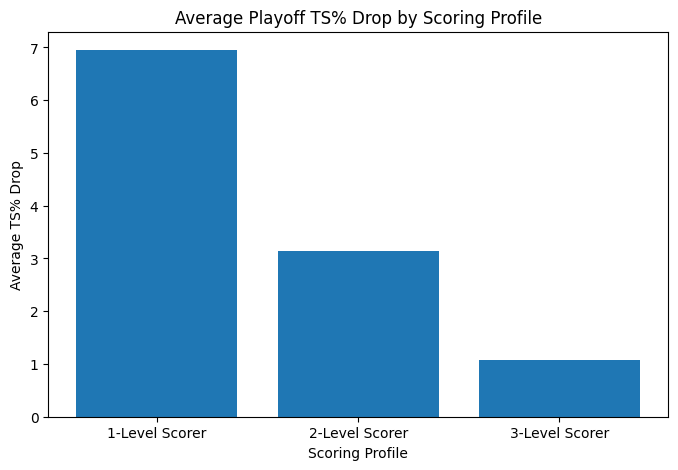

In [ ]:
# ============================================
# Step 20: Visualize Bar Chart TS Drop by Scoring Profile
# ============================================

# Sort scoring profiles in natural order
profile_order = ["1-Level Scorer", "2-Level Scorer", "3-Level Scorer"]

scoring_impact_chart = scoring_impact.set_index("Scoring_Profile").loc[profile_order].reset_index()

# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(
    scoring_impact_chart["Scoring_Profile"],
    scoring_impact_chart["Avg TS Change (%)"]
)

plt.title("Average Playoff TS% Drop by Scoring Profile")
plt.xlabel("Scoring Profile")
plt.ylabel("Average TS% Drop")
plt.xticks(rotation=0)
plt.show()

## ***Key Finding: Scoring Versatility and Playoff Stability***

The results show a clear pattern: players classified as 1-level scorers experienced the largest average decline in True Shooting Percentage during the playoffs, while 3-level scorers experienced the smallest decline.

This supports the idea that scoring versatility helps players maintain efficiency in playoff environments, where defenses are more targeted, physical, and matchup-specific.

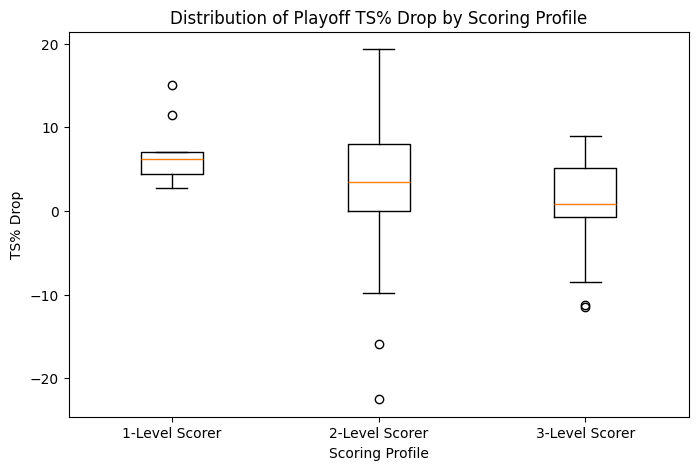

In [ ]:
# ============================================
# Step 21: Visualize TS Drop Distribution by Scoring Profile
# ============================================

# Averages are useful, but they can hide variation.
# This box plot shows the distribution of TS drop for each scoring profile,
# helping evaluate whether 3-level scorers are not only better on average,
# but also more stable as a group.

profile_order = ["1-Level Scorer", "2-Level Scorer", "3-Level Scorer"]

boxplot_data = [
    scoring_vs_performance[
        scoring_vs_performance["Scoring_Profile"] == profile
    ]["TS_drop"] * 100
    for profile in profile_order
]

plt.figure(figsize=(8, 5))
plt.boxplot(boxplot_data, tick_labels=profile_order)

plt.title("Distribution of Playoff TS% Drop by Scoring Profile")
plt.xlabel("Scoring Profile")
plt.ylabel("TS% Drop")
plt.show()

## ***Box Plot Insight***

1-level scorers show the most consistent performance, but consistently experience larger efficiency declines in the playoffs. In contrast, 2-level scorers exhibit the greatest variability, indicating that different two-level scoring archetypes translate very differently to playoff environments. 3-level scorers combine relatively low variance with the smallest average TS% decline, suggesting they are both more stable and more resilient under playoff conditions.

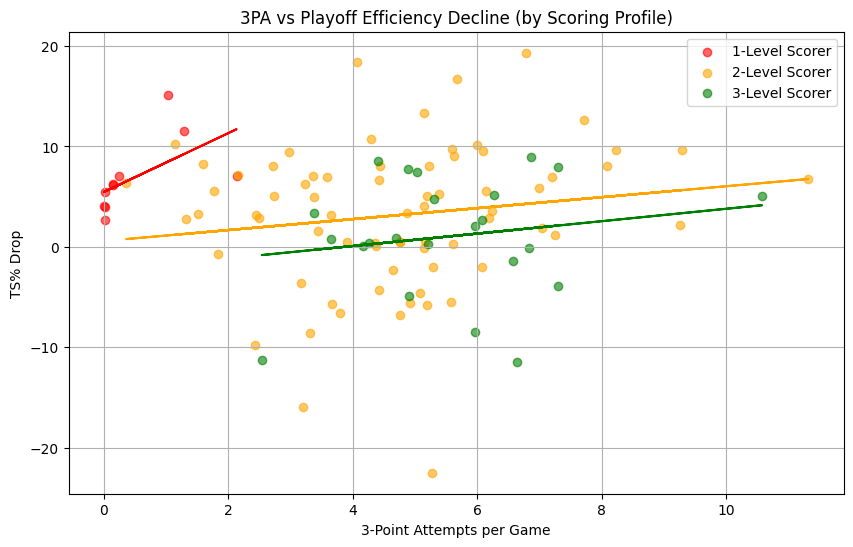

In [ ]:
# ============================================
# Step 24: Scatter Plot — Shot Profile vs TS Drop
# ============================================

# Create 3PA per game as a more intuitive metric than 3PA rate
scoring_vs_performance["ThreePA_per_game"] = (
    scoring_vs_performance["FGA_reg"] *
    scoring_vs_performance["Three_Rate"] /
    scoring_vs_performance["GP_reg"]
)

colors = {
    "1-Level Scorer": "red",
    "2-Level Scorer": "orange",
    "3-Level Scorer": "green"
}

plt.figure(figsize=(10, 6))

for profile, color in colors.items():
    subset = scoring_vs_performance[
        scoring_vs_performance["Scoring_Profile"] == profile
    ]

    x = subset["ThreePA_per_game"]
    y = subset["TS_drop"] * 100

    plt.scatter(x, y, label=profile, alpha=0.6, color=color)

    if len(x) > 1:
        m, b = np.polyfit(x, y, 1)
        plt.plot(x, m*x + b, color=color)

plt.xlabel("3-Point Attempts per Game")
plt.ylabel("TS% Drop")
plt.title("3PA vs Playoff Efficiency Decline (by Scoring Profile)")

plt.legend()
plt.grid(True)
plt.show()

### ***Scatter Plot Insight***

While there is a slight upward trend showing that higher three-point volume is associated with greater playoff TS% decline, this relationship is relatively weak and highly variable. The trend is most pronounced among 1-level scorers and weakest among 3-level scorers.

This suggests that heavy reliance on three-point shooting alone may increase vulnerability in the playoffs, but does not consistently determine efficiency decline. Instead, overall scoring versatility appears to mitigate this effect, as 3-level scorers maintain more stable performance even at higher three-point volumes.

## ***Step 25: Zone-Level Impact of Playoff Defense***

After establishing that 3-level scorers experience the smallest decline in overall efficiency, the next question becomes:

**Where on the court does playoff defense have the greatest impact?**

Rather than focusing on player archetypes, this step shifts the analysis to **shot location**, examining how shooting efficiency changes from the regular season to the playoffs across three primary zones:

- Interior (Rim / Restricted Area)
- Midrange
- Three-Point

By comparing field goal percentage (FG%) in each zone between the regular season and playoffs, this analysis isolates **how defensive intensity affects shot difficulty by location**.

The goal is to identify whether certain zones — particularly the midrange — remain more stable under playoff conditions, offering insight into which scoring areas are most resilient when defenses tighten.

In [ ]:
# ============================================
# Step 25A: Pull Playoff Shot Location Data
# ============================================

# After analyzing player archetypes, I now shift to zone-level analysis.
# The goal is to compare regular season vs playoff FG% by shot zone.

playoff_shot_location_request = leaguedashplayershotlocations.LeagueDashPlayerShotLocations(
    season=season,
    season_type_all_star="Playoffs"
)

playoff_shot_location_data = playoff_shot_location_request.get_data_frames()[0]

# Preview playoff shot location dataset
playoff_shot_location_data.head()

SHOT_CATEGORY                                                               \
columns       PLAYER_ID    PLAYER_NAME     TEAM_ID TEAM_ABBREVIATION   AGE   
0                203932   Aaron Gordon  1610612743               DEN  27.0   
1               1628988  Aaron Holiday  1610612737               ATL  26.0   
2                201143     Al Horford  1610612738               BOS  37.0   
3                203458       Alex Len  1610612758               SAC  30.0   
4               1629599    Amir Coffey  1610612746               LAC  26.0   

SHOT_CATEGORY          Restricted Area              In The Paint (Non-RA)  \
columns       NICKNAME             FGM   FGA FG_PCT                   FGM   
0                Aaron            65.0  98.0  0.663                   9.0   
1                Aaron             0.0   0.0  0.000                   0.0   
2                   Al            17.0  19.0  0.895                   5.0   
3                 Alex             7.0   8.0  0.875                   0.0   
4                 Amir             0.0   0.0  0.000                   0.0   

SHOT_CATEGORY  ... Right Corner 3 Above the Break 3            Backcourt       \
columns        ...         FG_PCT               FGM FGA FG_PCT       FGM  FGA   
0              ...          0.455                 8  21  0.381       0.0  1.0   
1              ...          0.000                 0   0  0.000       NaN  NaN   
2              ...          0.400                15  61  0.246       0.0  0.0   
3              ...          0.000                 0   0  0.000       0.0  0.0   
4              ...            NaN                 0   0  0.000       NaN  NaN   

SHOT_CATEGORY        Corner 3               
columns       FG_PCT      FGM   FGA FG_PCT  
0                0.0     10.0  24.0  0.417  
1                NaN      0.0   0.0  0.000  
2                0.0     13.0  33.0  0.394  
3                0.0      0.0   0.0  0.000  
4                NaN      NaN   NaN    NaN  

[5 rows x 30 columns]

In [ ]:
# ============================================
# Step 25B: Build Weighted Zone Makes/Attempts Tables
# ============================================

regular_zone = shot_location_data[
    [
        ("", "PLAYER_ID"),
        ("", "PLAYER_NAME"),
        ("Restricted Area", "FGM"),
        ("Restricted Area", "FGA"),
        ("In The Paint (Non-RA)", "FGM"),
        ("In The Paint (Non-RA)", "FGA"),
        ("Mid-Range", "FGM"),
        ("Mid-Range", "FGA"),
        ("Left Corner 3", "FGM"),
        ("Left Corner 3", "FGA"),
        ("Right Corner 3", "FGM"),
        ("Right Corner 3", "FGA"),
        ("Above the Break 3", "FGM"),
        ("Above the Break 3", "FGA")
    ]
].copy()

regular_zone.columns = [
    "PLAYER_ID", "PLAYER_NAME",
    "Reg_RA_FGM", "Reg_RA_FGA",
    "Reg_Paint_FGM", "Reg_Paint_FGA",
    "Reg_Mid_FGM", "Reg_Mid_FGA",
    "Reg_LC3_FGM", "Reg_LC3_FGA",
    "Reg_RC3_FGM", "Reg_RC3_FGA",
    "Reg_ATB3_FGM", "Reg_ATB3_FGA"
]

playoff_zone = playoff_shot_location_data[
    [
        ("", "PLAYER_ID"),
        ("", "PLAYER_NAME"),
        ("Restricted Area", "FGM"),
        ("Restricted Area", "FGA"),
        ("In The Paint (Non-RA)", "FGM"),
        ("In The Paint (Non-RA)", "FGA"),
        ("Mid-Range", "FGM"),
        ("Mid-Range", "FGA"),
        ("Left Corner 3", "FGM"),
        ("Left Corner 3", "FGA"),
        ("Right Corner 3", "FGM"),
        ("Right Corner 3", "FGA"),
        ("Above the Break 3", "FGM"),
        ("Above the Break 3", "FGA")
    ]
].copy()

playoff_zone.columns = [
    "PLAYER_ID", "PLAYER_NAME",
    "Playoff_RA_FGM", "Playoff_RA_FGA",
    "Playoff_Paint_FGM", "Playoff_Paint_FGA",
    "Playoff_Mid_FGM", "Playoff_Mid_FGA",
    "Playoff_LC3_FGM", "Playoff_LC3_FGA",
    "Playoff_RC3_FGM", "Playoff_RC3_FGA",
    "Playoff_ATB3_FGM", "Playoff_ATB3_FGA"
]

In [ ]:
# ============================================
# Step 25C: Aggregate Zone FG% Change
# ============================================

# Merge regular season and playoff zone data by player.
# This creates the comparison table needed to aggregate makes and attempts.
zone_fg_comparison = regular_zone.merge(
    playoff_zone,
    on="PLAYER_ID",
    how="inner",
    suffixes=("_reg", "_playoffs")
)

# For the final zone-level conclusion, I aggregate all makes and attempts first.
# This avoids giving low-volume players the same influence as high-volume players.
#
# This answers:
# "Across all qualified playoff players, how did each zone's FG% change from regular season to playoffs?"

zone_drop_summary = pd.DataFrame({
    "Zone": ["Interior", "Midrange", "Three"],

    "Regular FG%": [
        (
            zone_fg_comparison["Reg_RA_FGM"].sum() +
            zone_fg_comparison["Reg_Paint_FGM"].sum()
        ) / (
            zone_fg_comparison["Reg_RA_FGA"].sum() +
            zone_fg_comparison["Reg_Paint_FGA"].sum()
        ),

        zone_fg_comparison["Reg_Mid_FGM"].sum() /
        zone_fg_comparison["Reg_Mid_FGA"].sum(),

        (
            zone_fg_comparison["Reg_LC3_FGM"].sum() +
            zone_fg_comparison["Reg_RC3_FGM"].sum() +
            zone_fg_comparison["Reg_ATB3_FGM"].sum()
        ) / (
            zone_fg_comparison["Reg_LC3_FGA"].sum() +
            zone_fg_comparison["Reg_RC3_FGA"].sum() +
            zone_fg_comparison["Reg_ATB3_FGA"].sum()
        )
    ],

    "Playoff FG%": [
        (
            zone_fg_comparison["Playoff_RA_FGM"].sum() +
            zone_fg_comparison["Playoff_Paint_FGM"].sum()
        ) / (
            zone_fg_comparison["Playoff_RA_FGA"].sum() +
            zone_fg_comparison["Playoff_Paint_FGA"].sum()
        ),

        zone_fg_comparison["Playoff_Mid_FGM"].sum() /
        zone_fg_comparison["Playoff_Mid_FGA"].sum(),

        (
            zone_fg_comparison["Playoff_LC3_FGM"].sum() +
            zone_fg_comparison["Playoff_RC3_FGM"].sum() +
            zone_fg_comparison["Playoff_ATB3_FGM"].sum()
        ) / (
            zone_fg_comparison["Playoff_LC3_FGA"].sum() +
            zone_fg_comparison["Playoff_RC3_FGA"].sum() +
            zone_fg_comparison["Playoff_ATB3_FGA"].sum()
        )
    ]
})

# Change = Playoff FG% - Regular Season FG%
# Positive = zone became more efficient in playoffs
# Negative = zone became less efficient in playoffs
zone_drop_summary["FG% Change"] = (
    zone_drop_summary["Playoff FG%"] -
    zone_drop_summary["Regular FG%"]
)

# Convert to readable percentage-point format
zone_drop_summary["Regular FG%"] = (zone_drop_summary["Regular FG%"] * 100).round(1)
zone_drop_summary["Playoff FG%"] = (zone_drop_summary["Playoff FG%"] * 100).round(1)
zone_drop_summary["FG% Change"] = (zone_drop_summary["FG% Change"] * 100).round(2)

zone_drop_summary

,Zone,Regular FG%,Playoff FG%,FG% Change
0,Interior,58.6,55.9,-2.67
1,Midrange,42.8,43.3,0.49
2,Three,37.0,35.3,-1.71


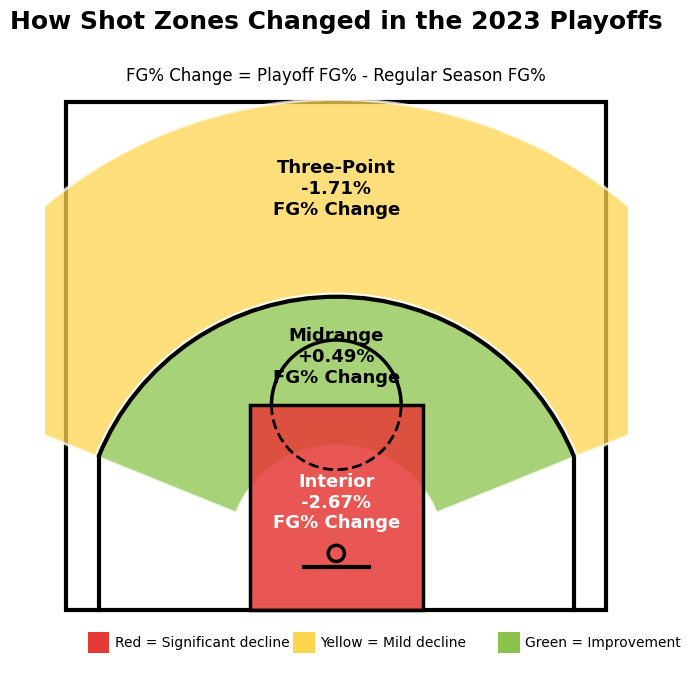

In [ ]:
# ============================================
# Step 26: Court-Style Zone FG% Change Map
# ============================================

# This visualization maps the aggregate zone FG% change from Step 25C
# onto a simplified half-court.
#
# FG% Change = Playoff FG% - Regular Season FG%
# Positive = better shooting in playoffs
# Negative = worse shooting in playoffs

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Arc, Circle, Wedge

# Pull values from Step 25C summary table
zone_values = dict(zip(zone_drop_summary["Zone"], zone_drop_summary["FG% Change"]))

interior_change = zone_values["Interior"]
midrange_change = zone_values["Midrange"]
three_change = zone_values["Three"]

# Traffic-light color system
def get_zone_color(value):
    if value > 0:
        return "#8BC34A"   # green = improvement
    elif value > -2:
        return "#FFD54F"   # yellow = mild decline
    else:
        return "#E53935"   # red = significant decline

interior_color = get_zone_color(interior_change)
midrange_color = get_zone_color(midrange_change)
three_color = get_zone_color(three_change)

fig, ax = plt.subplots(figsize=(10, 8))

# Court background
ax.set_facecolor("#F7D7A0")

# Court outline
ax.add_patch(Rectangle((-25, 0), 50, 47, fill=False, linewidth=3, edgecolor="black"))

# Three-point zone
ax.add_patch(Wedge(
    center=(0, 5.25),
    r=42,
    theta1=22,
    theta2=158,
    width=18,
    facecolor=three_color,
    alpha=0.75,
    edgecolor="white",
    linewidth=2
))

# Midrange zone
ax.add_patch(Wedge(
    center=(0, 5.25),
    r=24,
    theta1=22,
    theta2=158,
    width=14,
    facecolor=midrange_color,
    alpha=0.75,
    edgecolor="white",
    linewidth=2
))

# Interior / paint zone
ax.add_patch(Rectangle(
    (-8, 0), 16, 19,
    facecolor=interior_color,
    alpha=0.85,
    edgecolor="white",
    linewidth=2
))

# Court lines
ax.add_patch(Circle((0, 5.25), 0.75, fill=False, linewidth=2.5, edgecolor="black"))
ax.plot([-3, 3], [4, 4], color="black", linewidth=3)
ax.add_patch(Rectangle((-8, 0), 16, 19, fill=False, linewidth=2.5, edgecolor="black"))
ax.add_patch(Arc((0, 19), 12, 12, theta1=0, theta2=180, linewidth=2.5, edgecolor="black"))
ax.add_patch(Arc((0, 19), 12, 12, theta1=180, theta2=360, linewidth=2, edgecolor="black", linestyle="--"))
ax.add_patch(Arc((0, 5.25), 47.5, 47.5, theta1=22, theta2=158, linewidth=3, edgecolor="black"))
ax.plot([-22, -22], [0, 14], color="black", linewidth=3)
ax.plot([22, 22], [0, 14], color="black", linewidth=3)

# Labels
ax.text(
    0, 10,
    f"Interior\n{interior_change:+.2f}%\nFG% Change",
    ha="center",
    va="center",
    fontsize=13,
    weight="bold",
    color="white"
)

# Moved slightly lower so it does not overlap the free throw circle
ax.text(
    0, 23.5,
    f"Midrange\n{midrange_change:+.2f}%\nFG% Change",
    ha="center",
    va="center",
    fontsize=13,
    weight="bold",
    color="black"
)

ax.text(
    0, 39,
    f"Three-Point\n{three_change:+.2f}%\nFG% Change",
    ha="center",
    va="center",
    fontsize=13,
    weight="bold",
    color="black"
)

# Title + subtitle
ax.set_title(
    "How Shot Zones Changed in the 2023 Playoffs",
    fontsize=18,
    weight="bold",
    pad=22
)

ax.text(
    0, 49,
    "FG% Change = Playoff FG% - Regular Season FG%",
    ha="center",
    fontsize=12
)

# Legend
legend_y = -4

ax.add_patch(Rectangle((-23, legend_y), 2, 2, facecolor="#E53935"))
ax.text(-20.5, legend_y + 1, "Red = Significant decline", va="center", fontsize=10)

ax.add_patch(Rectangle((-4, legend_y), 2, 2, facecolor="#FFD54F"))
ax.text(-1.5, legend_y + 1, "Yellow = Mild decline", va="center", fontsize=10)

ax.add_patch(Rectangle((15, legend_y), 2, 2, facecolor="#8BC34A"))
ax.text(17.5, legend_y + 1, "Green = Improvement", va="center", fontsize=10)

# Layout
ax.set_xlim(-27, 27)
ax.set_ylim(-6, 51)
ax.set_aspect("equal")
ax.axis("off")

plt.show()

### ***Zone Map Insight***

The zone map reveals that playoff efficiency changes are not uniform across the floor. Interior scoring experienced the largest decline, three-point shooting also declined, while midrange efficiency slightly improved.

This is especially interesting because modern basketball analytics heavily emphasize threes and shots at the rim as the most efficient scoring options. However, this playoff data suggests that those areas also become the most disrupted under playoff defenses, where schemes are tighter, help defense is stronger, and shot quality declines.

In contrast, the midrange — often viewed as inefficient or outdated — appears to hold up better, and in this sample even slightly improves. This suggests that the midrange may be one of the most overlooked and undervalued skills in high-pressure playoff environments.

When combined with earlier findings that 3-level scorers experience the smallest drop in true shooting percentage, the data supports a broader conclusion: players who can access all three scoring levels — especially the midrange as a counter — are better equipped to maintain efficiency when defenses take away primary options.

# Multi-Season Validation

---

In [ ]:
# ============================================
# Step 27: Multi-Season Validation Pipeline
# ============================================

# This turns the single-season workflow into a reusable analysis function.
# It tests whether the relationship between scoring versatility and playoff
# TS% change holds across multiple modern NBA seasons.

import time

seasons_to_test = [
    "2014-15",
    "2015-16",
    "2016-17",
    "2017-18",
    "2018-19",
    "2019-20",
    "2020-21",
    "2021-22",
    "2022-23",
    "2023-24",
    "2024-25"
]

def pull_with_retry(request_function, retries=4, sleep_seconds=4):
    for attempt in range(retries):
        try:
            data = request_function().get_data_frames()[0]
            time.sleep(sleep_seconds)
            return data
        except Exception as error:
            print(f"Attempt {attempt + 1} failed: {error}")
            time.sleep(sleep_seconds * 2)

    raise Exception("NBA API failed after multiple attempts.")


def run_season_analysis(season):
    # Pull regular season box score data
    regular_data = pull_with_retry(
        lambda: leaguedashplayerstats.LeagueDashPlayerStats(
            season=season,
            season_type_all_star="Regular Season"
        )
    )

    # Pull playoff box score data
    playoff_data = pull_with_retry(
        lambda: leaguedashplayerstats.LeagueDashPlayerStats(
            season=season,
            season_type_all_star="Playoffs"
        )
    )

    # Select columns needed for TS%
    regular_selected = regular_data[
        ["PLAYER_ID", "PLAYER_NAME", "TEAM_ABBREVIATION", "GP", "PTS", "FGA", "FTA", "FG3A"]
    ].copy()

    playoff_selected = playoff_data[
        ["PLAYER_ID", "PLAYER_NAME", "TEAM_ABBREVIATION", "GP", "PTS", "FGA", "FTA", "FG3A"]
    ].copy()

    # Calculate regular season and playoff TS%
    regular_selected["TS_pct"] = (
        regular_selected["PTS"] /
        (2 * (regular_selected["FGA"] + 0.44 * regular_selected["FTA"]))
    )

    playoff_selected["Playoff_TS_pct"] = (
        playoff_selected["PTS"] /
        (2 * (playoff_selected["FGA"] + 0.44 * playoff_selected["FTA"]))
    )

    # Filter to meaningful samples
    regular_cleaned = regular_selected[
        (regular_selected["GP"] >= 30) &
        (regular_selected["FGA"] >= 300)
    ].copy()

    playoff_cleaned = playoff_selected[
        (playoff_selected["GP"] >= 3) &
        (playoff_selected["FGA"] >= 30)
    ].copy()

    regular_cleaned = regular_cleaned.replace([np.inf, -np.inf], np.nan).dropna()
    playoff_cleaned = playoff_cleaned.replace([np.inf, -np.inf], np.nan).dropna()

    # Compare regular season vs playoff TS%
    season_vs_playoffs = regular_cleaned.merge(
        playoff_cleaned,
        on="PLAYER_ID",
        how="inner",
        suffixes=("_reg", "_playoffs")
    )

    # Change = playoff TS% - regular season TS%
    # Negative = efficiency declined in playoffs
    season_vs_playoffs["TS_change"] = (
        season_vs_playoffs["Playoff_TS_pct"] -
        season_vs_playoffs["TS_pct"]
    )

    # Pull regular season shot location data
    shot_location_data_multi = pull_with_retry(
        lambda: leaguedashplayershotlocations.LeagueDashPlayerShotLocations(
            season=season,
            season_type_all_star="Regular Season"
        )
    )

    # Select shot profile columns
    shot_profile_multi = shot_location_data_multi[
        [
            ("", "PLAYER_ID"),
            ("", "PLAYER_NAME"),
            ("", "TEAM_ABBREVIATION"),
            ("Restricted Area", "FGA"),
            ("In The Paint (Non-RA)", "FGA"),
            ("Mid-Range", "FGA"),
            ("Left Corner 3", "FGA"),
            ("Right Corner 3", "FGA"),
            ("Above the Break 3", "FGA")
        ]
    ].copy()

    shot_profile_multi.columns = [
        "PLAYER_ID",
        "PLAYER_NAME",
        "TEAM_ABBREVIATION",
        "Restricted_Area_FGA",
        "Paint_Non_RA_FGA",
        "Midrange_FGA",
        "Left_Corner_3_FGA",
        "Right_Corner_3_FGA",
        "Above_Break_3_FGA"
    ]

    # Build three scoring levels
    shot_profile_multi["Interior_Attempts"] = (
        shot_profile_multi["Restricted_Area_FGA"] +
        shot_profile_multi["Paint_Non_RA_FGA"]
    )

    shot_profile_multi["Midrange_Attempts"] = shot_profile_multi["Midrange_FGA"]

    shot_profile_multi["Three_Attempts"] = (
        shot_profile_multi["Left_Corner_3_FGA"] +
        shot_profile_multi["Right_Corner_3_FGA"] +
        shot_profile_multi["Above_Break_3_FGA"]
    )

    shot_profile_multi["Total_Profile_Attempts"] = (
        shot_profile_multi["Interior_Attempts"] +
        shot_profile_multi["Midrange_Attempts"] +
        shot_profile_multi["Three_Attempts"]
    )

    # Keep meaningful shot-profile volume
    shot_profile_multi = shot_profile_multi[
        shot_profile_multi["Total_Profile_Attempts"] >= 300
    ].copy()

    # Calculate zone rates
    shot_profile_multi["Interior_Rate"] = (
        shot_profile_multi["Interior_Attempts"] /
        shot_profile_multi["Total_Profile_Attempts"]
    )

    shot_profile_multi["Midrange_Rate"] = (
        shot_profile_multi["Midrange_Attempts"] /
        shot_profile_multi["Total_Profile_Attempts"]
    )

    shot_profile_multi["Three_Rate"] = (
        shot_profile_multi["Three_Attempts"] /
        shot_profile_multi["Total_Profile_Attempts"]
    )

    # Classify scoring versatility
    scoring_level_threshold = 0.15

    shot_profile_multi["Scoring_Levels_Used"] = (
        (shot_profile_multi["Interior_Rate"] >= scoring_level_threshold).astype(int) +
        (shot_profile_multi["Midrange_Rate"] >= scoring_level_threshold).astype(int) +
        (shot_profile_multi["Three_Rate"] >= scoring_level_threshold).astype(int)
    )

    def classify_scorer(levels):
        if levels == 3:
            return "3-Level Scorer"
        elif levels == 2:
            return "2-Level Scorer"
        else:
            return "1-Level Scorer"

    shot_profile_multi["Scoring_Profile"] = (
        shot_profile_multi["Scoring_Levels_Used"].apply(classify_scorer)
    )

    # Merge scoring profile with TS change
    scoring_vs_performance_multi = season_vs_playoffs.merge(
        shot_profile_multi[
            ["PLAYER_ID", "Scoring_Profile", "Interior_Rate", "Midrange_Rate", "Three_Rate"]
        ],
        on="PLAYER_ID",
        how="inner"
    )

    # Summarize by scoring profile
    scoring_impact_multi = scoring_vs_performance_multi.groupby("Scoring_Profile").agg(
        Avg_TS_Change=("TS_change", "mean"),
        Player_Count=("PLAYER_ID", "count")
    ).reset_index()

    scoring_impact_multi["Season"] = season
    scoring_impact_multi["Avg_TS_Change_%"] = (
        scoring_impact_multi["Avg_TS_Change"] * 100
    ).round(2)

    return scoring_impact_multi


multi_season_results = []

for season in seasons_to_test:
    try:
        print(f"Running {season}...")
        season_result = run_season_analysis(season)
        multi_season_results.append(season_result)
    except Exception as error:
        print(f"Skipping {season} because of error: {error}")

multi_season_results = pd.concat(multi_season_results, ignore_index=True)

multi_season_results

Running 2014-15...
Running 2015-16...
Running 2016-17...
Running 2017-18...
Running 2018-19...
Running 2019-20...
Running 2020-21...
Running 2021-22...
Running 2022-23...
Running 2023-24...
Running 2024-25...


,Scoring_Profile,Avg_TS_Change,Player_Count,Season,Avg_TS_Change_%
0,1-Level Scorer,-0.020499,9,2014-15,-2.05
1,2-Level Scorer,-0.041400,37,2014-15,-4.14
2,3-Level Scorer,-0.013653,65,2014-15,-1.37
3,1-Level Scorer,-0.048347,10,2015-16,-4.83
4,2-Level Scorer,-0.035380,37,2015-16,-3.54
5,3-Level Scorer,-0.013765,64,2015-16,-1.38
6,1-Level Scorer,0.017388,8,2016-17,1.74
7,2-Level Scorer,-0.010922,52,2016-17,-1.09
8,3-Level Scorer,-0.005547,55,2016-17,-0.55
9,1-Level Scorer,-0.027720,9,2017-18,-2.77


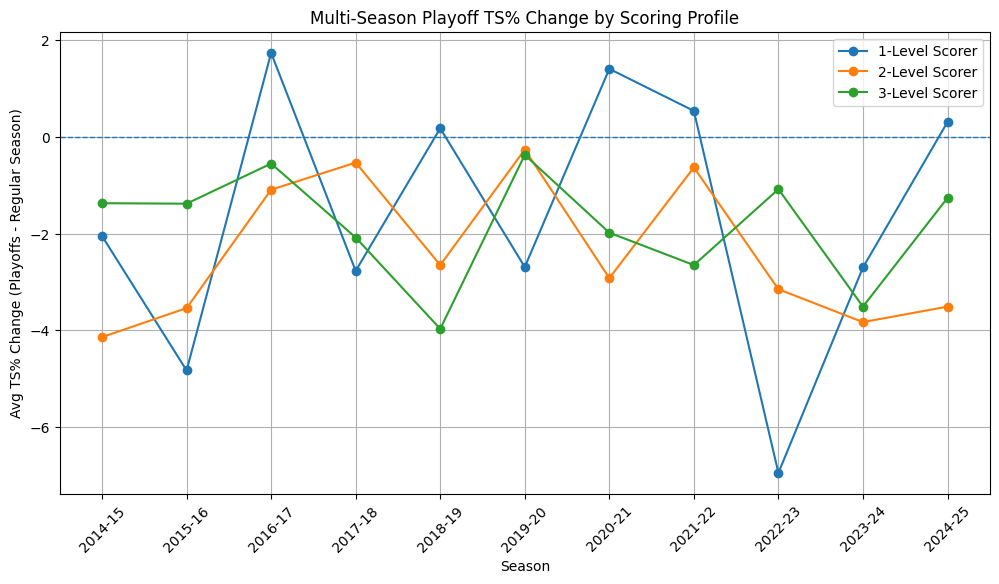

In [ ]:
# ============================================
# Step 28A: Multi-Season TS% Change Line Chart
# ============================================

# This chart shows whether each scoring profile becomes more or less stable
# across multiple playoff seasons.

profile_order = ["1-Level Scorer", "2-Level Scorer", "3-Level Scorer"]

plt.figure(figsize=(12, 6))

for profile in profile_order:
    profile_data = multi_season_results[
        multi_season_results["Scoring_Profile"] == profile
    ].copy()

    plt.plot(
        profile_data["Season"],
        profile_data["Avg_TS_Change_%"],
        marker="o",
        label=profile
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Multi-Season Playoff TS% Change by Scoring Profile")
plt.xlabel("Season")
plt.ylabel("Avg TS% Change (Playoffs - Regular Season)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

# ***📈 Line Chart (Trend Over Time) Insight:***

The line chart reveals that playoff efficiency changes fluctuate from season to season, but a consistent pattern still emerges across time. While all scoring profiles experience variability, 2-level scorers repeatedly show the most volatility and the largest negative swings, indicating greater sensitivity to playoff defenses.

In contrast:

3-level scorers maintain relatively steadier performance across seasons, suggesting adaptability against different defensive schemes
1-level scorers show smaller declines and occasional positive spikes, though this is likely influenced by lower usage and more controlled roles

A key takeaway from the trend is:

*“The exact numbers change each season, but the hierarchy remains consistent."*

Even when certain seasons deviate, 2-level scorers consistently reappear as the least stable group, reinforcing that this is not a one-season anomaly, but a recurring pattern.

This suggests that playoff defenses are not just reacting to skill, but systematically exploiting players who lack either elite specialization or full versatility.

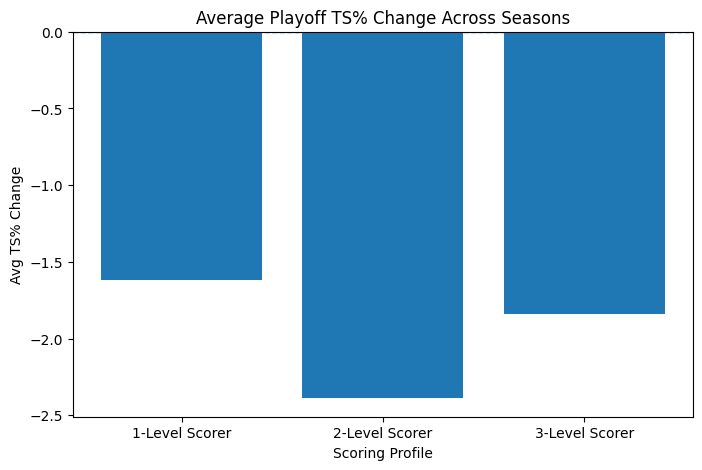

,Scoring_Profile,Avg_TS_Change_Across_Seasons,Avg_Player_Count
0,1-Level Scorer,-1.62,9.818182
1,2-Level Scorer,-2.39,56.727273
2,3-Level Scorer,-1.84,42.818182


In [ ]:
# ============================================
# Step 28B: Average Multi-Season TS% Change by Scoring Profile
# ============================================

# This aggregates all tested seasons to compare the overall average playoff
# TS% change for each scoring profile.

multi_season_average = multi_season_results.groupby("Scoring_Profile").agg(
    Avg_TS_Change_Across_Seasons=("Avg_TS_Change_%", "mean"),
    Avg_Player_Count=("Player_Count", "mean")
).reset_index()

multi_season_average["Avg_TS_Change_Across_Seasons"] = (
    multi_season_average["Avg_TS_Change_Across_Seasons"].round(2)
)

multi_season_average = (
    multi_season_average
    .set_index("Scoring_Profile")
    .loc[profile_order]
    .reset_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    multi_season_average["Scoring_Profile"],
    multi_season_average["Avg_TS_Change_Across_Seasons"]
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Average Playoff TS% Change Across Seasons")
plt.xlabel("Scoring Profile")
plt.ylabel("Avg TS% Change")
plt.xticks(rotation=0)
plt.show()

multi_season_average

#📊 ***Bar Chart Insight (Multi-Season Average) Insight:***

When averaging playoff efficiency changes across all seasons, a clear hierarchy emerges:

2-level scorers experience the largest average decline in efficiency
1-level and 3-level scorers perform more similarly and show smaller declines

Importantly, this does not mean specialists outperform 3-level scorers. Their results are relatively close, but for different reasons:

1-level scorers (specialists) benefit from clearly defined roles and lower defensive attention
3-level scorers, often primary offensive options, face the toughest defenses but maintain efficiency through adaptability

Meanwhile, 2-level scorers fall in between; lacking both the elite specialization and the complete versatility needed to consistently counter playoff adjustments.

The key takeaway is:

*“It’s not that one extreme is better; it’s that the middle is the most vulnerable.”*

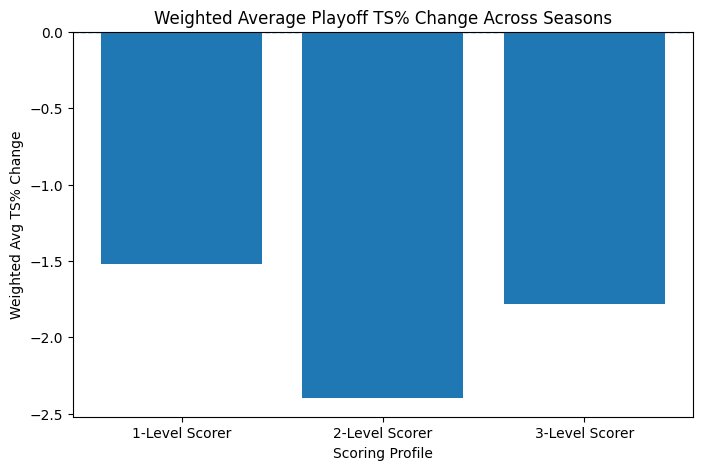

,Scoring_Profile,Weighted_TS_Change_%,Total_Player_Seasons
0,1-Level Scorer,-1.52,108.0
1,2-Level Scorer,-2.40,624.0
2,3-Level Scorer,-1.78,471.0


In [37]:
# ============================================
# Step 28C: Weighted Multi-Season TS% Change
# ============================================

# The previous multi-season chart treats each season/profile average equally.
# This weighted version accounts for player volume by weighting each season-profile result
# by the number of players in that group.

weighted_multi_season_summary = (
    multi_season_results
    .groupby("Scoring_Profile", group_keys=False)
    .apply(
        lambda group: pd.Series({
            "Weighted_TS_Change_%": (
                (group["Avg_TS_Change_%"] * group["Player_Count"]).sum()
                / group["Player_Count"].sum()
            ),
            "Total_Player_Seasons": group["Player_Count"].sum()
        }),
        include_groups=False
    )
    .reset_index()
)

weighted_multi_season_summary["Weighted_TS_Change_%"] = (
    weighted_multi_season_summary["Weighted_TS_Change_%"].round(2)
)

weighted_multi_season_summary = (
    weighted_multi_season_summary
    .set_index("Scoring_Profile")
    .loc[["1-Level Scorer", "2-Level Scorer", "3-Level Scorer"]]
    .reset_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    weighted_multi_season_summary["Scoring_Profile"],
    weighted_multi_season_summary["Weighted_TS_Change_%"]
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Weighted Average Playoff TS% Change Across Seasons")
plt.xlabel("Scoring Profile")
plt.ylabel("Weighted Avg TS% Change")
plt.xticks(rotation=0)
plt.show()

weighted_multi_season_summary

#📊 ***Weighted Bar Chart Insight:***

After weighting the data by player volume and sample size, the same pattern holds and becomes more statistically reliable:

2-level scorers still show the largest decline in efficiency
1-level and 3-level scorers remain relatively close in performance

This confirms that the earlier findings are not driven by small sample sizes or outliers, but reflect a broader, league-wide trend.

A deeper interpretation reveals:

3-level scorers, typically stars, absorb the highest defensive pressure yet remain stable due to their ability to score at all levels.

1-level scorers, while limited, benefit from reduced defensive focus and clearly defined offensive roles.

This explains why their efficiency changes appear similar even though their responsibilities are very different.

The most important takeaway from the weighted analysis is:

*"Players who are neither highly specialized nor fully versatile are the easiest for playoff defenses to target."*

Across trends, averages, and weighted results, the conclusion remains consistent: playoff defenses don’t just punish weakness—they punish players without a clear offensive identity.

# Multi-Season Shot Zone Stability Analysis

---

In [ ]:
# ============================================
# Step 29A: Multi-Season Zone FG% Change Pipeline
# ============================================

# This repeats the zone-level FG% analysis across multiple seasons.
# It compares Regular Season FG% vs Playoff FG% by zone:
# Interior, Midrange, and Three.

def run_zone_analysis_for_season(season):
    # Pull regular season shot location data
    regular_shot_data = pull_with_retry(
        lambda: leaguedashplayershotlocations.LeagueDashPlayerShotLocations(
            season=season,
            season_type_all_star="Regular Season"
        )
    )

    # Pull playoff shot location data
    playoff_shot_data = pull_with_retry(
        lambda: leaguedashplayershotlocations.LeagueDashPlayerShotLocations(
            season=season,
            season_type_all_star="Playoffs"
        )
    )

    # Select makes and attempts by zone
    regular_zone = regular_shot_data[
        [
            ("", "PLAYER_ID"),
            ("Restricted Area", "FGM"),
            ("Restricted Area", "FGA"),
            ("In The Paint (Non-RA)", "FGM"),
            ("In The Paint (Non-RA)", "FGA"),
            ("Mid-Range", "FGM"),
            ("Mid-Range", "FGA"),
            ("Left Corner 3", "FGM"),
            ("Left Corner 3", "FGA"),
            ("Right Corner 3", "FGM"),
            ("Right Corner 3", "FGA"),
            ("Above the Break 3", "FGM"),
            ("Above the Break 3", "FGA")
        ]
    ].copy()

    regular_zone.columns = [
        "PLAYER_ID",
        "Reg_RA_FGM", "Reg_RA_FGA",
        "Reg_Paint_FGM", "Reg_Paint_FGA",
        "Reg_Mid_FGM", "Reg_Mid_FGA",
        "Reg_LC3_FGM", "Reg_LC3_FGA",
        "Reg_RC3_FGM", "Reg_RC3_FGA",
        "Reg_ATB3_FGM", "Reg_ATB3_FGA"
    ]

    playoff_zone = playoff_shot_data[
        [
            ("", "PLAYER_ID"),
            ("Restricted Area", "FGM"),
            ("Restricted Area", "FGA"),
            ("In The Paint (Non-RA)", "FGM"),
            ("In The Paint (Non-RA)", "FGA"),
            ("Mid-Range", "FGM"),
            ("Mid-Range", "FGA"),
            ("Left Corner 3", "FGM"),
            ("Left Corner 3", "FGA"),
            ("Right Corner 3", "FGM"),
            ("Right Corner 3", "FGA"),
            ("Above the Break 3", "FGM"),
            ("Above the Break 3", "FGA")
        ]
    ].copy()

    playoff_zone.columns = [
        "PLAYER_ID",
        "Playoff_RA_FGM", "Playoff_RA_FGA",
        "Playoff_Paint_FGM", "Playoff_Paint_FGA",
        "Playoff_Mid_FGM", "Playoff_Mid_FGA",
        "Playoff_LC3_FGM", "Playoff_LC3_FGA",
        "Playoff_RC3_FGM", "Playoff_RC3_FGA",
        "Playoff_ATB3_FGM", "Playoff_ATB3_FGA"
    ]

    # Merge regular season and playoff zone data
    zone_comparison = regular_zone.merge(
        playoff_zone,
        on="PLAYER_ID",
        how="inner"
    )

    # Aggregate makes and attempts first, then calculate FG%
    zone_summary = pd.DataFrame({
        "Zone": ["Interior", "Midrange", "Three"],

        "Regular FG%": [
            (
                zone_comparison["Reg_RA_FGM"].sum() +
                zone_comparison["Reg_Paint_FGM"].sum()
            ) / (
                zone_comparison["Reg_RA_FGA"].sum() +
                zone_comparison["Reg_Paint_FGA"].sum()
            ),

            zone_comparison["Reg_Mid_FGM"].sum() /
            zone_comparison["Reg_Mid_FGA"].sum(),

            (
                zone_comparison["Reg_LC3_FGM"].sum() +
                zone_comparison["Reg_RC3_FGM"].sum() +
                zone_comparison["Reg_ATB3_FGM"].sum()
            ) / (
                zone_comparison["Reg_LC3_FGA"].sum() +
                zone_comparison["Reg_RC3_FGA"].sum() +
                zone_comparison["Reg_ATB3_FGA"].sum()
            )
        ],

        "Playoff FG%": [
            (
                zone_comparison["Playoff_RA_FGM"].sum() +
                zone_comparison["Playoff_Paint_FGM"].sum()
            ) / (
                zone_comparison["Playoff_RA_FGA"].sum() +
                zone_comparison["Playoff_Paint_FGA"].sum()
            ),

            zone_comparison["Playoff_Mid_FGM"].sum() /
            zone_comparison["Playoff_Mid_FGA"].sum(),

            (
                zone_comparison["Playoff_LC3_FGM"].sum() +
                zone_comparison["Playoff_RC3_FGM"].sum() +
                zone_comparison["Playoff_ATB3_FGM"].sum()
            ) / (
                zone_comparison["Playoff_LC3_FGA"].sum() +
                zone_comparison["Playoff_RC3_FGA"].sum() +
                zone_comparison["Playoff_ATB3_FGA"].sum()
            )
        ]
    })

    # Change = Playoff FG% - Regular Season FG%
    zone_summary["FG% Change"] = (
        zone_summary["Playoff FG%"] -
        zone_summary["Regular FG%"]
    )

    zone_summary["Season"] = season

    # Convert to percentage-point format
    zone_summary["Regular FG%"] = (zone_summary["Regular FG%"] * 100).round(1)
    zone_summary["Playoff FG%"] = (zone_summary["Playoff FG%"] * 100).round(1)
    zone_summary["FG% Change"] = (zone_summary["FG% Change"] * 100).round(2)

    return zone_summary


multi_season_zone_results = []

for season in seasons_to_test:
    try:
        print(f"Running zone analysis for {season}...")
        zone_result = run_zone_analysis_for_season(season)
        multi_season_zone_results.append(zone_result)
    except Exception as error:
        print(f"Skipping {season} because of error: {error}")

multi_season_zone_results = pd.concat(multi_season_zone_results, ignore_index=True)

multi_season_zone_results

Running zone analysis for 2014-15...
Running zone analysis for 2015-16...
Running zone analysis for 2016-17...
Running zone analysis for 2017-18...
Running zone analysis for 2018-19...
Running zone analysis for 2019-20...
Running zone analysis for 2020-21...
Running zone analysis for 2021-22...
Running zone analysis for 2022-23...
Running zone analysis for 2023-24...
Running zone analysis for 2024-25...


,Zone,Regular FG%,Playoff FG%,FG% Change,Season
0,Interior,54.5,52.4,-2.05,2014-15
1,Midrange,40.5,37.0,-3.56,2014-15
2,Three,36.1,34.6,-1.53,2014-15
3,Interior,54.9,52.1,-2.78,2015-16
4,Midrange,40.4,39.1,-1.22,2015-16
5,Three,36.1,35.8,-0.26,2015-16
6,Interior,55.9,56.3,0.36,2016-17
7,Midrange,41.1,39.8,-1.36,2016-17
8,Three,36.9,36.4,-0.44,2016-17
9,Interior,56.7,55.8,-0.92,2017-18


In [ ]:
# ============================================
# Step 29B: Average Zone FG% Change Across Seasons
# ============================================

multi_zone_avg = multi_season_zone_results.groupby("Zone").agg(
    Avg_FG_Change=("FG% Change", "mean")
).reset_index()

multi_zone_avg["Avg_FG_Change"] = multi_zone_avg["Avg_FG_Change"].round(2)

multi_zone_avg = (
    multi_zone_avg
    .set_index("Zone")
    .loc[["Interior", "Midrange", "Three"]]
    .reset_index()
)

multi_zone_avg

,Zone,Avg_FG_Change
0,Interior,-1.66
1,Midrange,-0.86
2,Three,-1.26


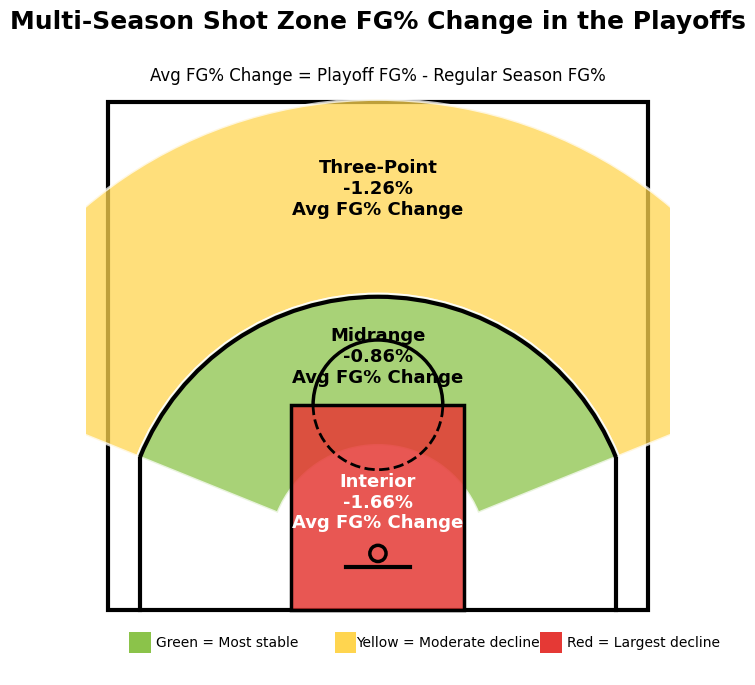

In [ ]:
# ============================================
# Step 29C: Multi-Season Court Zone Map
# ============================================

# For the multi-season chart, all zones may decline.
# So the color logic is relative:
# Green = smallest decline / most stable
# Yellow = moderate decline
# Red = largest decline

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Arc, Circle, Wedge

zone_values = dict(zip(multi_zone_avg["Zone"], multi_zone_avg["Avg_FG_Change"]))

interior_change = zone_values["Interior"]
midrange_change = zone_values["Midrange"]
three_change = zone_values["Three"]

# Rank zones by stability.
# Higher FG% Change = better / more stable.
sorted_zones = sorted(zone_values.items(), key=lambda x: x[1], reverse=True)

zone_colors = {
    sorted_zones[0][0]: "#8BC34A",  # most stable
    sorted_zones[1][0]: "#FFD54F",  # middle
    sorted_zones[2][0]: "#E53935"   # largest decline
}

interior_color = zone_colors["Interior"]
midrange_color = zone_colors["Midrange"]
three_color = zone_colors["Three"]

fig, ax = plt.subplots(figsize=(10, 8))

# Court background
ax.set_facecolor("#F7D7A0")

# Court outline
ax.add_patch(Rectangle((-25, 0), 50, 47, fill=False, linewidth=3, edgecolor="black"))

# Three-point zone
ax.add_patch(Wedge(
    center=(0, 5.25),
    r=42,
    theta1=22,
    theta2=158,
    width=18,
    facecolor=three_color,
    alpha=0.75,
    edgecolor="white",
    linewidth=2
))

# Midrange zone
ax.add_patch(Wedge(
    center=(0, 5.25),
    r=24,
    theta1=22,
    theta2=158,
    width=14,
    facecolor=midrange_color,
    alpha=0.75,
    edgecolor="white",
    linewidth=2
))

# Interior / paint zone
ax.add_patch(Rectangle(
    (-8, 0), 16, 19,
    facecolor=interior_color,
    alpha=0.85,
    edgecolor="white",
    linewidth=2
))

# Court lines
ax.add_patch(Circle((0, 5.25), 0.75, fill=False, linewidth=2.5, edgecolor="black"))
ax.plot([-3, 3], [4, 4], color="black", linewidth=3)
ax.add_patch(Rectangle((-8, 0), 16, 19, fill=False, linewidth=2.5, edgecolor="black"))
ax.add_patch(Arc((0, 19), 12, 12, theta1=0, theta2=180, linewidth=2.5, edgecolor="black"))
ax.add_patch(Arc((0, 19), 12, 12, theta1=180, theta2=360, linewidth=2, edgecolor="black", linestyle="--"))
ax.add_patch(Arc((0, 5.25), 47.5, 47.5, theta1=22, theta2=158, linewidth=3, edgecolor="black"))
ax.plot([-22, -22], [0, 14], color="black", linewidth=3)
ax.plot([22, 22], [0, 14], color="black", linewidth=3)

# Labels
ax.text(
    0, 10,
    f"Interior\n{interior_change:+.2f}%\nAvg FG% Change",
    ha="center",
    va="center",
    fontsize=13,
    weight="bold",
    color="white" if zone_colors["Interior"] == "#E53935" else "black"
)

ax.text(
    0, 23.5,
    f"Midrange\n{midrange_change:+.2f}%\nAvg FG% Change",
    ha="center",
    va="center",
    fontsize=13,
    weight="bold",
    color="black"
)

ax.text(
    0, 39,
    f"Three-Point\n{three_change:+.2f}%\nAvg FG% Change",
    ha="center",
    va="center",
    fontsize=13,
    weight="bold",
    color="black"
)

ax.set_title(
    "Multi-Season Shot Zone FG% Change in the Playoffs",
    fontsize=18,
    weight="bold",
    pad=22
)

ax.text(
    0, 49,
    "Avg FG% Change = Playoff FG% - Regular Season FG%",
    ha="center",
    fontsize=12
)

# Legend
legend_y = -4

ax.add_patch(Rectangle((-23, legend_y), 2, 2, facecolor="#8BC34A"))
ax.text(-20.5, legend_y + 1, "Green = Most stable", va="center", fontsize=10)

ax.add_patch(Rectangle((-4, legend_y), 2, 2, facecolor="#FFD54F"))
ax.text(-2, legend_y + 1, "Yellow = Moderate decline", va="center", fontsize=10)

ax.add_patch(Rectangle((15, legend_y), 2, 2, facecolor="#E53935"))
ax.text(17.5, legend_y + 1, "Red = Largest decline", va="center", fontsize=10)

ax.set_xlim(-27, 27)
ax.set_ylim(-6, 51)
ax.set_aspect("equal")
ax.axis("off")

plt.show()

# ***Multi-Season Zone Map Insight***

Across multiple modern NBA seasons, all three major scoring zones decline in efficiency during the playoffs, but they do not decline equally.

Interior scoring shows the largest drop, likely because playoff defenses protect the rim more aggressively and reduce easy paint opportunities. Three-point efficiency also declines, reflecting tighter closeouts, stronger scouting, and fewer clean catch-and-shoot looks.

Midrange scoring shows the smallest decline, making it the most stable zone across the sample. This does not mean the midrange is the most efficient shot overall. Rather, it suggests that the midrange is the hardest zone for playoff defenses to eliminate completely.

This connects directly to the scoring profile findings: specialists can remain stable through clear roles, while 3-level scorers remain resilient because they have access to counters when the rim and three-point line become harder to reach. The most vulnerable group is 2-level scorers, who often lack either elite specialization or full versatility.

The broader takeaway is:

####*Playoff basketball does not simply reward the most efficient shots... it rewards the shots defenses cannot fully take away.*

# Conclusions & Analysis

---

##This project explored how scoring versatility relates to playoff efficiency decline in the modern NBA.

Using shot-location data from the NBA API, players were grouped into scoring archetypes based on whether they scored effectively from one, two, or all three major scoring zones: interior, midrange, and three-point.

The original hypothesis expected 3-level scorers to experience the smallest playoff efficiency decline because of their versatility and adaptability against playoff defenses.

However, the multi-season results revealed a more nuanced pattern.

Across ten NBA seasons:

- 1-level scorers experienced the smallest average TS% decline
- 2-level scorers experienced the largest decline
- 3-level scorers remained relatively stable and consistently outperformed 2-level scorers

The findings suggest that playoff stability may come from either:
- elite specialization
- or complete versatility

While players in the middle that are neither elite specilaist nor fully verasitle may become easier to scheme against.

Zone-level analysis added further context:
- Interior efficiency declined the most in the playoffs
- Three-point efficiency also declined under increased defensive pressure
- Midrange efficiency proved to be the most stable scoring zone across seasons

Importantly, this does not imply that the midrange is the most efficient shot in basketball. Instead, it suggests that midrange scoring may be the hardest playoff shot type for defenses to fully eliminate.

# Final Reflection

---

###*In an era where basketball increasingly optimizes for threes and layups, the playoffs may still remind us why the midrange never truly disappeared.*

Modern basketball analytics often emphasizes the value of three-point shooting and shots at the rim; and for good reason. Those areas typically produce the highest regular-season efficiency.

But this project suggests that playoff basketball introduces a different question:

> Which shots can defenses actually take away?

Across multiple seasons, the midrange consistently proved to be the most stable scoring zone under playoff pressure. While it may not always be the most efficient shot during the regular season, it appears to become one of the most sustainable when defenses tighten, spacing shrinks, and possessions become more physical and deliberate.

The broader takeaway is not that players should abandon efficiency analytics, but that adaptability matters just as much as optimization. In high-pressure environments, the ability to access difficult but reliable scoring options may ultimately separate good scorers from sustainable playoff scorers.

In many ways,

###*The midrange is basketball’s classic counter. It isn't always the first option... but it shouldn't be the last one.*